/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


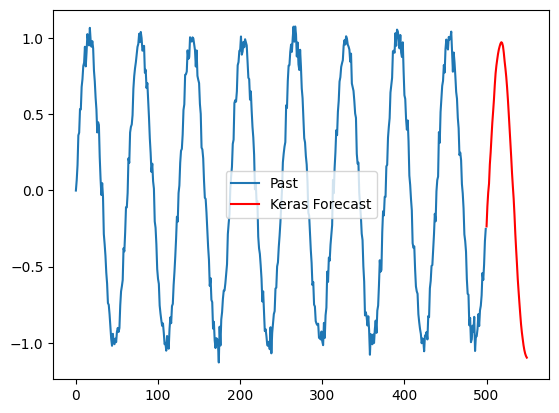

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Prepare Data (Same wave as before)
data = np.sin(np.linspace(0, 50, 500)) + np.random.normal(0, 0.05, 500)
window_size = 10

X, Y = [], []
for i in range(len(data) - window_size):
    X.append(data[i:i + window_size])
    Y.append(data[i + window_size])

X, Y = np.array(X), np.array(Y)

# 2. Build the Model (Very concise in Keras)
model = Sequential([
    Dense(32, activation='relu', input_shape=(window_size,)),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 3. Train
model.fit(X, Y, epochs=100, verbose=0) # verbose=0 keeps the output clean

# 4. Recursive Generation (The Autoregressive Part)
forecast = []
current_window = data[-window_size:].tolist()

for _ in range(50):
    prediction = model.predict(np.array([current_window]), verbose=0)
    val = prediction[0][0]
    forecast.append(val)
    current_window.pop(0) # Remove the oldest
    current_window.append(val) # Add the new prediction

# 5. Visualize
plt.plot(data, label="Past")
plt.plot(range(len(data), len(data)+50), forecast, label="Keras Forecast", color="red")
plt.legend()
plt.show()
